In [1]:
import numpy as np
import numba
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# all distances are in Schwarzschild coordinates

In [3]:
# size of pixel
pixel_size = 0.025
# number of pixel in x direction
width_pixels = 160
# number of pixel in z direction
height_pixels = 120

# distance from observer to camera
d_obs_cam = 4
# distance from BH to camera
d_bh_cam = 10
# camera z offset
z_offset_cam = 0.5
# Schwarzschild radius, once r is smaller than this value, light can not get out of the horizon
r_s = 1
# accretion range
accretion_r_min = 2
accretion_r_max = 6

In [4]:
# position of pixel in 2D (x, y) space
@numba.njit
def get_init_xy(wi, hi):
    # position of the pixel
    xyz = np.array([
        -width_pixels * pixel_size / 2 + pixel_size / 2 + wi * pixel_size,
        -d_bh_cam,
        -height_pixels * pixel_size / 2 + pixel_size / 2 + hi * pixel_size + z_offset_cam,
    ])
    # position of the observer
    observer = np.array([0, -(d_obs_cam + d_bh_cam), z_offset_cam])
    # direction of ray
    dxyzdl = xyz - observer
    dxyzdl = dxyzdl / np.linalg.norm(dxyzdl)
    
    # convert to 2D space
    e = -xyz[-1] / dxyzdl[-1]
    accretion = xyz + e * dxyzdl
    accretion = accretion / np.linalg.norm(accretion)
    if accretion[1] < 0:
        accretion = -accretion
    # accretion = np.array([0.0, 1.0, 0.0])
    
    x0 = np.dot(xyz, accretion)
    y0 = np.sqrt(np.dot(xyz, xyz) - x0**2)
    if xyz[-1] < 0:
        y0 = -y0

    dxdl0 = np.dot(dxyzdl, accretion)
    dydl0 = np.sqrt(1 - dxdl0**2)
    if dxyzdl[-1] < 0:
        dydl0 = -dydl0
    return x0, y0, dxdl0, dydl0

# position of pixel in 2D (r, phi) space
@numba.njit
def get_init_rphi(wi, hi):
    x0, y0, dxdl0, dydl0 = get_init_xy(wi, hi)
    r0 = np.hypot(x0, y0)
    phi0 = np.arctan2(y0, x0)
    drdl0 = drdl(x0, y0, dxdl0, dydl0)
    dphidl0 = dphidl(x0, y0, dxdl0, dydl0)
    u0 = drdl0
    L = r0**2 * dphidl0
    return r0, u0, phi0, L

In [5]:
# the initial derivation of r
@numba.njit
def drdl(x, y, dxdl, dydl):
    return (x * dxdl + y * dydl) / np.hypot(x, y)

# the initial derivation of phi
@numba.njit
def dphidl(x, y, dxdl, dydl):
    return (x * dydl - y * dxdl) / (x*x + y*y)

In [6]:
@numba.njit
def f(y, r_s, L):
    r, u, phi = y
    drdl = u
    dudl = (r - 1.5 * r_s) * (L**2 / r**4)
    dphidl = L / r**2
    return np.array([drdl, dudl, dphidl])

# update state array using RK4
@numba.njit
def rk4_step(y, dl, r_s, L):
    k1 = f(y, r_s, L)
    k2 = f(y + 0.5 * dl * k1, r_s, L)
    k3 = f(y + 0.5 * dl * k2, r_s, L)
    k4 = f(y + dl * k3, r_s, L)
    yp = y + (dl / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    yp[-1] = yp[-1] % (2 * np.pi)
    return yp

In [7]:
# whether the beam crosses accretion
@numba.njit
def across_accretion(r0, phi0, r1, phi1):
    if (r0 > accretion_r_min and r0 < accretion_r_max) and (r1 > accretion_r_min and r1 < accretion_r_max):
        if (phi0 * phi1 < 0) or ((phi0 - np.pi) * (phi1 - np.pi) < 0):
            return True
    return False

In [8]:
dl = 1e-2
N = int(2e3)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:01<00:00, 101.46it/s]


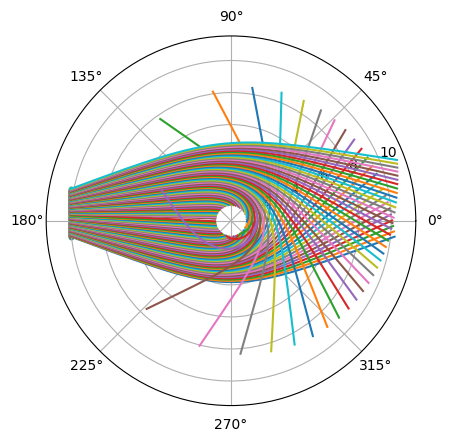

In [9]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

wi = width_pixels // 2
for hi in tqdm(range(height_pixels)):
    # for wi in range(width_pixels)):
    r0, u0, phi0, L = get_init_rphi(wi, hi)
    
    y = np.array([r0, u0, phi0])

    trajectory = [y.copy()]
    
    for _ in range(N):
        y = rk4_step(y, dl, r_s, L)
        trajectory.append(y.copy())
        if y[0] <= r_s:
            break
    
    trajectory = np.array(trajectory)
    r_vals = trajectory[:, 0]
    phi_vals = trajectory[:, 2]
    ax.scatter(phi_vals[0], r_vals[0], s=10)
    ax.plot(phi_vals, r_vals)

plt.show()

In [10]:
seen = np.empty((height_pixels, width_pixels))
for hi in tqdm(range(height_pixels)):
    for wi in range(width_pixels):
        r0, u0, phi0, L = get_init_rphi(wi, hi)
        
        y0 = np.array([r0, u0, phi0])
        
        for _ in range(N):
            y1 = rk4_step(y0, dl, r_s, L)
            if across_accretion(y0[0], y0[2], y1[0], y1[2]):
                seen[hi, wi] = 1.0
                break
            if y1[0] <= r_s:
                seen[hi, wi] = 0.0
                break
            # update state array
            y0 = y1.copy()
        else:
            seen[hi, wi] = 0.5

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:39<00:00,  3.01it/s]


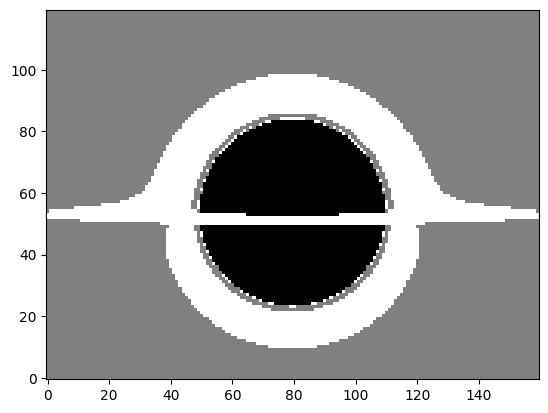

In [11]:
fig, ax = plt.subplots()

ax.imshow(seen, origin='lower', cmap='gray')
# ax.axis('off')

plt.show()